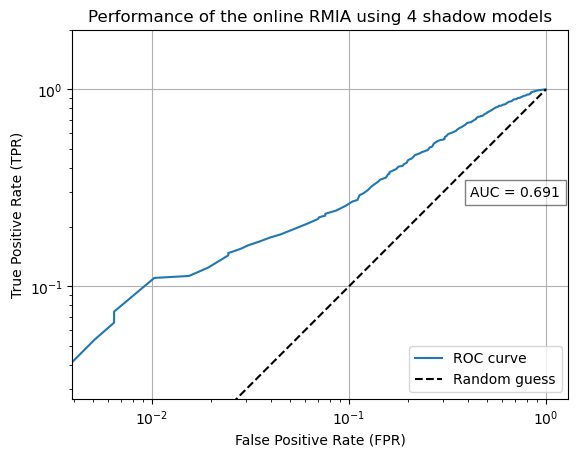

In [4]:
import pandas as pd

import matplotlib.pyplot as plt
import numpy as np

# Load the CSV file
n_sm = 4
online_flag = True
attack_flag = 'rmia'
bin_masked = True

if online_flag:
    attack_type = 'online'
else:
    attack_type = 'offline'



if attack_flag == 'rmia':
    attack_name = 'rmia'
    attack_title_name = 'RMIA'
else:
    attack_name = 'lira'
    attack_title_name = 'LiRA'

if bin_masked:
    data_path = f'./leakpro_output/results_bin_masked_{n_sm}sm/{attack_name}/ROC.csv'
else: 
    data_path = f'./Thesis results mia/{attack_type}_attacks_2ep/leakpro_output/results_{attack_type}_{n_sm}sm/{attack_name}/ROC.csv'
data = pd.read_csv(data_path)
# Extract the columns
fpr = data.iloc[:, 0].to_numpy()
tpr = data.iloc[:, 1].to_numpy()
if attack_flag == 'rmia':
    fpr = np.append(np.array([1]), fpr)
    tpr = np.append(np.array([1]), tpr)
else :
    fpr = np.append(fpr, np.array([1]))
    tpr = np.append(tpr, np.array([1]))
roc_auc = abs(np.trapz(x=fpr, y=tpr))
# Generate the plot
plt.figure()
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0, 1], [0, 1], 'k--', label='Random guess')
plt.title(f'Performance of the {attack_type} {attack_title_name} using {n_sm} shadow models')

# Add labels and title
# Log scale
plt.xscale('log')
plt.yscale('log')
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')


plt.axis('equal')
plt.legend(loc='lower right')
plt.grid(True)
plt.text(
            0.7,
            0.3,
            f"AUC = {abs(roc_auc):.03f}",
            horizontalalignment="center",
            verticalalignment="center",
            bbox={"facecolor": "white", "alpha": 0.5},
        )

# Save the plot as svg using title name
#plt.show()
plt.savefig(f'./Thesis_figs/binary_masked_{attack_name}_{attack_type}_{n_sm}_ROC.svg', format='svg')


In [ ]:
# Read out how many epochs were used in the shadow models
